# Figure 6D — corrected Rippl-AI probability heatmap (portable cache version)

This version is designed so that **plotting does not depend on `rippl_AI`, `keras`, or the original raw-data paths**. By default, it runs in **plot-only** mode and tries to load a complete Figure 6D analysis cache, or assemble one from cached Figure 6B analysis data plus cached Figure 6D Rippl-AI probabilities. If those caches are not available, it stops with a clear message and does **not** try to open `/data` or `/scratch`.

Only if you intentionally set `PLOT_ONLY = False` does the notebook fall back to the original raw-data workflow, which requires the original `.mat` files and the `rippl_AI` package.


In [1]:
import os
import glob
import collections
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Portable cache / workflow settings
# -----------------------------
EXPECTED_GLOBAL_N = 31847
EXPECTED_SELECTED_N = 30162
EXCLUDED_PATIENTS = {"EC130_200", "EC183_200"}
OUTPUT_STEM = "Figure6_D_corrected"

# Default: plot using cached results only, without raw data or rippl_AI.
PLOT_ONLY = True
FORCE_REBUILD_D_ANALYSIS_CACHE = False
FORCE_RECOMPUTE_RIPPL_AI = False

CACHE_DIR = os.environ.get("FIGURE6_CACHE_DIR", os.getcwd())
D_ANALYSIS_CACHE_PATH = os.path.join(CACHE_DIR, OUTPUT_STEM + "_analysis_cache.npz")
D_RIPPL_AI_CACHE_PATH = os.path.join(CACHE_DIR, OUTPUT_STEM + "_ripplAI_predictions.npz")
B_ANALYSIS_CACHE_PATH = os.path.join(CACHE_DIR, "Figure6_B_analysis_cache.npz")
B_GRID_PATH = os.path.join(CACHE_DIR, "Figure6_B_grid.npz")

# Raw-data paths are only used when PLOT_ONLY=False.
pathname = "/scratch/dazhang/MATLAB/"
raw_root = "/data/an/preprocessed/"
rdata_root = "/data/an/transformed/RR_h_referential_wSPKS/"

print("Current working directory:", os.getcwd())
print("Cache directory:", CACHE_DIR)


Current working directory: /Users/dazhang/Documents/ripple_IED_paper/Figure_6
Cache directory: /Users/dazhang/Documents/ripple_IED_paper/Figure_6


In [2]:
pt_ch_mapping = {'EC130_200': [1, 13], 'EC133_200': [282, 291, 292, 293], 'EC135_200': [303], 'EC137_200': [257, 258, 259, 269], 'EC143_200': [339], 'EC157_200': [321, 332, 333, 334], 'EC162_200': [85, 86], 'EC175_200': [301, 302], 'EC183_200': [290], 'EC186_200': [299, 300, 301], 'EC187_200': [309, 310], 'EC191_200': [2, 3, 4], 'EC196_200': [300, 301, 303], 'EC219_200': [399, 400, 402, 403], 'EC220_200': [53, 54, 76, 77], 'EC221_200': [376, 377], 'EC222_200': [267, 268, 269, 270]}

patient_num = {'EC130_200': 1465, 'EC133_200': 1220, 'EC135_200': 344, 'EC137_200': 7222, 'EC143_200': 881, 'EC157_200': 4747, 'EC162_200': 2398, 'EC175_200': 518, 'EC183_200': 220, 'EC186_200': 1710, 'EC187_200': 1315, 'EC191_200': 642, 'EC196_200': 594, 'EC219_200': 2015, 'EC220_200': 2572, 'EC221_200': 859, 'EC222_200': 3125}

empty_blocks = {'EC133_ch282': {'B67'}, 'EC137_ch259': {'B176'}, 'EC183_ch290': {'B132', 'B142', 'B139'}, 'EC220_ch55': {'B24', 'B27'}, 'EC220_ch75': {'B24', 'B27'}, 'EC221_ch375': {'B36', 'B47'}, 'EC221_ch374': {'B36', 'B47'}, 'EC196_ch302': {'B21'}, 'EC183_ch289': {'B132', 'B164', 'B142', 'B139'}, 'EC175_ch303': {'B11'}, 'EC157_ch322': {'B46'}, 'EC143_ch330': {'B35'}, 'EC137_ch260': {'B185', 'B158'}, 'EC133_ch294': {'B60', 'B67'}, 'EC133_ch281': {'B60', 'B67'}, 'EC130_ch2': {'B8'}}

assert sum(patient_num.values()) == EXPECTED_GLOBAL_N
assert sum(v for k, v in patient_num.items() if k not in EXCLUDED_PATIENTS) == EXPECTED_SELECTED_N

## 1. Load a complete D cache, or assemble one from cached inputs

The notebook first tries to load `Figure6_D_corrected_analysis_cache.npz`. If that file is missing, it tries to assemble the required arrays from **(a)** `Figure6_B_analysis_cache.npz` and **(b)** `Figure6_D_corrected_ripplAI_predictions.npz`. In plot-only mode, failure to find these caches raises a clear error and does not touch the original raw-data paths.


In [3]:
# Helper to load the first existing key from an NPZ file.
def npz_get(npz_obj, key_candidates, required=True, transform=None):
    for key in key_candidates:
        if key in npz_obj:
            value = npz_obj[key]
            return transform(value) if transform is not None else value
    if required:
        raise KeyError(f"Missing keys {key_candidates}; available keys: {list(npz_obj.keys())}")
    return None

analysis_cache_loaded = False
assembled_from_caches = False
all_vectors = None
all_specs_label = None
embedding = None
all_res_array = None
file_list = None
file_slices = None
all_specs = None

# Preferred: complete Figure 6D analysis cache.
if (not FORCE_REBUILD_D_ANALYSIS_CACHE) and os.path.isfile(D_ANALYSIS_CACHE_PATH):
    print(f"Loading complete Figure 6D analysis cache: {D_ANALYSIS_CACHE_PATH}")
    with np.load(D_ANALYSIS_CACHE_PATH, allow_pickle=True) as cache:
        all_vectors = np.asarray(npz_get(cache, ["all_vectors", "global_vectors", "all_specs"], transform=np.asarray))
        all_specs_label = np.asarray(npz_get(cache, ["all_specs_label", "global_labels", "patient_labels"], transform=np.asarray))
        embedding = np.asarray(npz_get(cache, ["embedding", "global_embedding", "umap_embedding"], transform=np.asarray), dtype=float)
        all_res_array = np.asarray(npz_get(cache, ["all_res_array", "global_probabilities", "ripplai_probabilities"], transform=np.asarray), dtype=float)
        file_list = npz_get(cache, ["file_list"], required=False, transform=lambda x: np.asarray(x, dtype=object))
    analysis_cache_loaded = True
    print("Loaded complete Figure 6D analysis cache.")

# Second choice: assemble D from cached Figure 6B analysis + cached D Rippl-AI predictions.
if not analysis_cache_loaded:
    have_b_analysis = os.path.isfile(B_ANALYSIS_CACHE_PATH)
    have_d_prob = os.path.isfile(D_RIPPL_AI_CACHE_PATH)

    if have_b_analysis and have_d_prob:
        print("Assembling Figure 6D analysis state from cached Figure 6B analysis + D Rippl-AI cache...")
        with np.load(B_ANALYSIS_CACHE_PATH, allow_pickle=True) as bcache:
            all_vectors = np.asarray(npz_get(bcache, ["all_vectors", "global_vectors", "all_specs"], transform=np.asarray))
            all_specs_label = np.asarray(npz_get(bcache, ["all_specs_label", "global_labels", "patient_labels"], transform=np.asarray))
            embedding = np.asarray(npz_get(bcache, ["embedding", "global_embedding", "umap_embedding"], transform=np.asarray), dtype=float)
            file_list = npz_get(bcache, ["file_list"], required=False, transform=lambda x: np.asarray(x, dtype=object))

        with np.load(D_RIPPL_AI_CACHE_PATH, allow_pickle=True) as dcache:
            all_res_array = np.asarray(npz_get(dcache, ["all_res_array", "global_probabilities", "ripplai_probabilities"], transform=np.asarray), dtype=float)
            cached_file_list = npz_get(dcache, ["file_list"], required=False, transform=lambda x: np.asarray(x, dtype=object))

        if file_list is not None and cached_file_list is not None:
            if len(file_list) != len(cached_file_list) or not np.array_equal(file_list, cached_file_list):
                raise AssertionError(
                    "Figure 6B analysis cache and Figure 6D Rippl-AI cache disagree on canonical file order/content."
                )

        assert all_vectors.shape[0] == EXPECTED_GLOBAL_N, all_vectors.shape
        assert embedding.shape == (EXPECTED_GLOBAL_N, 2), embedding.shape
        assert len(all_specs_label) == EXPECTED_GLOBAL_N, len(all_specs_label)
        assert len(all_res_array) == EXPECTED_GLOBAL_N, len(all_res_array)
        assert np.isfinite(all_res_array).all()

        np.savez_compressed(
            D_ANALYSIS_CACHE_PATH,
            all_vectors=all_vectors,
            all_specs_label=all_specs_label,
            embedding=embedding,
            all_res_array=all_res_array,
            file_list=file_list if file_list is not None else np.array([], dtype=object),
        )
        print(f"Saved complete Figure 6D analysis cache: {D_ANALYSIS_CACHE_PATH}")
        analysis_cache_loaded = True
        assembled_from_caches = True

# Plot-only mode: stop here if caches are insufficient.
if PLOT_ONLY and not analysis_cache_loaded:
    checks = [
        ("Complete Figure 6D analysis cache", D_ANALYSIS_CACHE_PATH),
        ("Figure 6D Rippl-AI cache", D_RIPPL_AI_CACHE_PATH),
        ("Figure 6B analysis cache", B_ANALYSIS_CACHE_PATH),
        ("Figure 6B grid", B_GRID_PATH),
    ]
    lines = [
        "Figure 6D plot-only mode: cannot find a complete cache or the inputs needed to assemble it.",
        "No original raw-data files or rippl_AI imports were used.",
        f"Current working directory: {os.getcwd()}",
        f"Cache directory: {CACHE_DIR}",
        "Required: D analysis cache OR (D Rippl-AI cache + B analysis cache + B grid cache).",
    ]
    for label, path in checks:
        lines.append(f"  {label}: {'FOUND' if os.path.isfile(path) else 'MISSING'} — {path}")
    lines.extend([
        "Move the NPZ files into CACHE_DIR, or set FIGURE6_CACHE_DIR to their folder.",
        "If the D Rippl-AI cache does not exist, create it once on the lab machine where rippl_AI and the original source data are accessible.",
        "To intentionally use original source data on that machine, set PLOT_ONLY=False.",
    ])
    raise FileNotFoundError("\n".join(lines))

# Raw-data fallback (only when intentionally enabled).
if not analysis_cache_loaded:
    print("No usable portable cache found. Falling back to raw-data workflow because PLOT_ONLY=False.")
    import h5py
    from scipy.io import loadmat

    file_list = []
    file_slices = {}
    all_specs_parts = []
    patient_label_parts = []
    row_offset = 0

    for patient, channel_list in pt_ch_mapping.items():
        patient_files = 0
        for cur_channel in channel_list:
            pattern = os.path.join(pathname, patient, "*.mat")
            for filename in sorted(glob.glob(pattern)):
                if "ls_ripple" not in filename or "binsize_1_" in filename:
                    continue
                if f"Channel_{cur_channel}_" not in filename or "-empty" in filename:
                    continue

                filename = os.path.abspath(filename)
                if filename in file_slices:
                    raise AssertionError(f"Repeated feature file: {filename}")
                specs = np.asarray(loadmat(filename)["ls_ripple"])
                if specs.ndim != 2 or specs.shape[1] != 60:
                    raise AssertionError(f"Unexpected feature shape in {filename}: {specs.shape}")

                n = len(specs)
                file_list.append(filename)
                file_slices[filename] = slice(row_offset, row_offset + n)
                all_specs_parts.append(specs)
                patient_label_parts.append(np.full(n, patient, dtype=object))
                row_offset += n
                patient_files += n

        print(f"{patient}: feature rows={patient_files}, expected={patient_num[patient]}")
        assert patient_files == patient_num[patient], (
            f"Incorrect feature count for {patient}: {patient_files} != {patient_num[patient]}"
        )

    all_specs = np.concatenate(all_specs_parts, axis=0)
    all_specs_label = np.concatenate(patient_label_parts, axis=0)
    all_vectors = np.asarray(all_specs)
    assert all_vectors.shape == (EXPECTED_GLOBAL_N, 60)
    assert len(file_slices) == len(file_list)
    print(f"Global features: {all_vectors.shape}; feature files: {len(file_list)}")


Loading complete Figure 6D analysis cache: /Users/dazhang/Documents/ripple_IED_paper/Figure_6/Figure6_D_corrected_analysis_cache.npz
Loaded complete Figure 6D analysis cache.


## 2. UMAP on all 31,847 candidates

If a portable cache already supplied the global embedding, this cell simply validates and reuses it. Otherwise, in raw-data mode, it computes the UMAP embedding using the original Figure 6B/D parameters.


In [4]:
if analysis_cache_loaded:
    assert embedding.shape == (EXPECTED_GLOBAL_N, 2)
    assert np.isfinite(embedding).all()
    print("Using cached global UMAP embedding:", embedding.shape)
else:
    import umap.umap_ as umap

    embedding = umap.UMAP(
        n_components=2,
        min_dist=0.2,
        metric="euclidean",
        n_neighbors=15,
        random_state=42,
        n_epochs=100,
        verbose=True,
    ).fit_transform(all_vectors)
    assert embedding.shape == (EXPECTED_GLOBAL_N, 2)
    assert np.isfinite(embedding).all()
    print("Global UMAP embedding:", embedding.shape)


Using cached global UMAP embedding: (31847, 2)


## 3. Load or compute Rippl-AI probabilities

If the complete D analysis cache was already loaded or assembled, this cell simply reuses `all_res_array`. In raw-data mode, it supports the original cached probability workflow; `rippl_AI` is imported **only when needed**.


In [5]:
if analysis_cache_loaded:
    assert len(all_res_array) == EXPECTED_GLOBAL_N
    assert np.isfinite(all_res_array).all()
    print(f"Using cached/already-assembled Rippl-AI probabilities: {len(all_res_array)}")
else:
    import h5py
    from scipy.io import loadmat
    import rippl_AI

    def load_rdata_field(f, field):
        """Same MATLAB v7.3 Rdata reference handling used by original Figure6_D."""
        data = np.array(f["q"]["Rdata"][field])
        if data.dtype == object:
            return [np.array(f[ref]) for ref in data.flatten() if isinstance(ref, h5py.Reference)]
        return [data]

    def read_block_names(f):
        refs = np.asarray(f["q"]["blocks"])
        if refs.ndim == 2 and refs.shape[0] == 1:
            refs = refs[0]
        else:
            refs = refs.flatten()
        names = []
        for ref in refs:
            codes = np.asarray(f[ref]).flatten()
            names.append("".join(chr(int(c)) for c in codes))
        return names

    cache_loaded = False
    canonical_file_array = np.asarray(file_list, dtype=object)
    cache_path = os.path.abspath(D_RIPPL_AI_CACHE_PATH)

    if (not FORCE_RECOMPUTE_RIPPL_AI) and os.path.isfile(cache_path):
        print(f"Loading cached Rippl-AI probabilities from: {cache_path}")
        with np.load(cache_path, allow_pickle=True) as cache:
            cached_file_list = cache["file_list"]
            cached_all_res = np.asarray(cache["all_res_array"], dtype=float)

        if len(cached_file_list) != len(canonical_file_array):
            print("Cache ignored: file-list length mismatch.")
        elif not np.array_equal(cached_file_list, canonical_file_array):
            mismatch = np.flatnonzero(cached_file_list != canonical_file_array)
            first = int(mismatch[0]) if len(mismatch) else None
            print("Cache ignored: canonical file order/content changed.")
            if first is not None:
                print("First mismatch:")
                print("  cached  :", cached_file_list[first])
                print("  current :", canonical_file_array[first])
        elif len(cached_all_res) != EXPECTED_GLOBAL_N:
            print(
                f"Cache ignored: probability length mismatch "
                f"({len(cached_all_res)} vs {EXPECTED_GLOBAL_N})."
            )
        elif not np.isfinite(cached_all_res).all():
            print("Cache ignored: cached probabilities contain non-finite values.")
        else:
            all_res_array = cached_all_res
            cache_loaded = True
            print(f"Loaded cached Rippl-AI probabilities: {len(all_res_array)}")

    if not cache_loaded:
        print("Computing Rippl-AI probabilities from raw data...")
        prob_by_file = {}
        canonical_files = set(file_list)
        architectures = ["XGBOOST", "SVM", "LSTM", "CNN1D", "CNN2D"]

        for patient, channel_list in pt_ch_mapping.items():
            pt = patient[:-4]
            first_channel = channel_list[0]
            first_rdata = os.path.join(
                rdata_root, pt, "AN", f"{pt}_AN_ch{first_channel}_wSPKS.mat"
            )
            with h5py.File(first_rdata, "r") as f:
                blocks = read_block_names(f)
            print(f"\n{patient}: {len(blocks)} MATLAB blocks")

            for each_channel in channel_list:
                rdata_file = os.path.join(
                    rdata_root, pt, "AN", f"{pt}_AN_ch{each_channel}_wSPKS.mat"
                )
                with h5py.File(rdata_file, "r") as f:
                    ripple_blocks = load_rdata_field(f, "ripples")
                    spike_blocks = load_rdata_field(f, "Rspikes_THISchannel")

                if not (len(ripple_blocks) == len(spike_blocks) == len(blocks)):
                    raise AssertionError(
                        f"Block count mismatch in {rdata_file}: "
                        f"ripples={len(ripple_blocks)}, spikes={len(spike_blocks)}, "
                        f"block names={len(blocks)}"
                    )

                for block_number, (ripples, spikes, block_name) in enumerate(
                    zip(ripple_blocks, spike_blocks, blocks), start=1
                ):
                    if block_name in empty_blocks.get(f"{pt}_ch{each_channel}", set()):
                        continue

                    feature_path = os.path.abspath(os.path.join(
                        pathname, patient,
                        f"ls_ripple_{pt}_Channel_{each_channel}_binsize_10_Block_{block_number}.mat"
                    ))
                    if feature_path not in canonical_files:
                        continue
                    if feature_path in prob_by_file:
                        raise AssertionError(f"Duplicate Rippl-AI prediction: {feature_path}")

                    ripples = np.atleast_2d(ripples)
                    spikes = np.atleast_1d(spikes)
                    if ripples.shape == (1, 2) and spikes.shape == (2,):
                        continue

                    raw_file = os.path.join(
                        raw_root, pt, f"{pt}_{block_name}", "MAT files",
                        f"{pt}_{block_name}_notched.mat"
                    )
                    a = loadmat(raw_file)
                    raw_signal = np.hstack([a["d"][:, each_channel]])
                    clean_lfp = np.nan_to_num(
                        raw_signal[:, np.newaxis], nan=0.0, posinf=1e5, neginf=-1e5
                    )
                    clean_lfp = np.clip(clean_lfp, -65000, 65000)

                    centers = np.asarray([
                        int(np.mean(event)) for event in np.vstack([ripples.T])
                    ], dtype=int)
                    output = []
                    for arch in architectures:
                        channels = [0, -1, -1, -1, -1, -1, -1, -1]
                        swr_prob, _ = rippl_AI.predict(
                            clean_lfp, 512, arch=arch, model_number=1, channels=channels
                        )
                        output.append(swr_prob)
                    ens_input = np.array(output).transpose()
                    prob_ens = np.asarray(rippl_AI.predict_ens(ens_input)).reshape(-1)

                    if len(centers) and (centers.min() < 0 or centers.max() >= len(prob_ens)):
                        raise IndexError(
                            f"Event center outside probability sequence: {feature_path}; "
                            f"centers={centers.min()}..{centers.max()}, n={len(prob_ens)}"
                        )
                    block_probs = np.asarray(prob_ens[centers], dtype=float)
                    expected_rows = file_slices[feature_path].stop - file_slices[feature_path].start
                    if len(block_probs) != expected_rows:
                        raise AssertionError(
                            f"ROW ALIGNMENT ERROR: {feature_path}: "
                            f"Rippl-AI events={len(block_probs)} vs features={expected_rows}. "
                            "Check within-block candidate order and event filtering."
                        )
                    prob_by_file[feature_path] = block_probs

                print(f"  {pt} ch{each_channel}: total aligned files so far={len(prob_by_file)}")

        missing = sorted(canonical_files - set(prob_by_file))
        extra = sorted(set(prob_by_file) - canonical_files)
        if missing or extra:
            raise AssertionError(
                f"File alignment failed: {len(missing)} missing, {len(extra)} extra. "
                f"First missing files: {missing[:10]}; first extra files: {extra[:10]}"
            )

        all_res_array = np.concatenate([prob_by_file[f] for f in file_list])
        assert len(all_res_array) == EXPECTED_GLOBAL_N
        assert np.isfinite(all_res_array).all()

        np.savez_compressed(
            cache_path,
            file_list=canonical_file_array,
            all_res_array=all_res_array,
        )
        print(f"Saved Rippl-AI cache: {cache_path}")

    print(f"Aligned Rippl-AI probabilities: {len(all_res_array)}")


Using cached/already-assembled Rippl-AI probabilities: 31847


## 4. Select the exact 30,162 candidates and fit the same KMeans model

In [6]:
selected_global_idx = np.flatnonzero(
    ~np.isin(all_specs_label, list(EXCLUDED_PATIENTS))
)
assert len(selected_global_idx) == EXPECTED_SELECTED_N

each_pt_embedding = embedding[selected_global_idx]
each_pt_probs = all_res_array[selected_global_idx]
each_pt_name_list = all_specs_label[selected_global_idx]
each_pt_vectors = all_vectors[selected_global_idx]

assert each_pt_embedding.shape == (EXPECTED_SELECTED_N, 2)
assert len(each_pt_probs) == len(each_pt_name_list) == EXPECTED_SELECTED_N
assert np.isfinite(each_pt_probs).all()
assert not np.isin(each_pt_name_list, list(EXCLUDED_PATIENTS)).any()

kmeans_label = KMeans(
    n_clusters=5,
    random_state=920,
    n_init=10,
).fit(each_pt_embedding)
print("Global candidates:", len(embedding))
print("Selected candidates:", len(each_pt_probs))
print("Selected patients:", len(np.unique(each_pt_name_list)))
print("Probability range:", each_pt_probs.min(), each_pt_probs.max())

Global candidates: 31847
Selected candidates: 30162
Selected patients: 15
Probability range: 0.0020215834956616163 0.9896982908248901


## 4b. Save a portable Figure 6D analysis cache

After `all_vectors`, `all_specs_label`, `embedding`, and `all_res_array` are available, save a portable cache so future plotting can run without `rippl_AI`, `keras`, or raw-data access.


In [7]:
np.savez_compressed(
    D_ANALYSIS_CACHE_PATH,
    all_vectors=all_vectors,
    all_specs_label=all_specs_label,
    embedding=embedding,
    all_res_array=all_res_array,
    selected_global_idx=selected_global_idx,
    each_pt_embedding=each_pt_embedding,
    each_pt_probs=each_pt_probs,
    each_pt_name_list=each_pt_name_list,
    file_list=np.asarray(file_list, dtype=object) if file_list is not None else np.array([], dtype=object),
)
print(f"Saved/updated portable Figure 6D analysis cache: {D_ANALYSIS_CACHE_PATH}")


Saved/updated portable Figure 6D analysis cache: /Users/dazhang/Documents/ripple_IED_paper/Figure_6/Figure6_D_corrected_analysis_cache.npz


## 5. Use Figure 6B as the **single geometry reference** for the 20 × 20 heatmap

Run `Figure6_B_corrected.ipynb` first, in the **same working directory** (or change `B_GRID_PATH` below). Figure 6D reads B's saved bin edges, embedding and candidate counts instead of independently constructing bin edges. This avoids an exact-equality error when `x_bins` was made at a different point in execution or saved from a different grid calculation. The code still stops if the selected candidates, coordinates or per-bin counts truly disagree.


In [8]:
# Exact Figure 6B geometry: use one set of saved bin edges for BOTH figures.
B_GRID_PATH = "Figure6_B_grid.npz"  # Change to absolute path if notebooks run in different directories.
print("Reading Figure 6B reference:", os.path.abspath(B_GRID_PATH))
if not os.path.isfile(B_GRID_PATH):
    raise FileNotFoundError(
        f"Missing {os.path.abspath(B_GRID_PATH)}. Run Figure6_B_corrected.ipynb "
        "through its 20x20 heatmap cell first, or set B_GRID_PATH explicitly."
    )

with np.load(B_GRID_PATH, allow_pickle=False) as ref:
    b_selected_idx = ref["selected_global_idx"].copy()
    b_embedding = ref["each_pt_embedding"].copy()
    b_x_bins = ref["x_bins"].copy()
    b_y_bins = ref["y_bins"].copy()
    b_grid_count = ref["grid_count"].copy()

assert np.array_equal(b_selected_idx, selected_global_idx), (
    "B/D selected candidates differ. Confirm the same feature files and ordering."
)
assert np.array_equal(b_embedding, each_pt_embedding), (
    "B/D UMAP embeddings differ. For a truly common geometry, use B's exact "
    "embedding in D; independently rerunning UMAP is not an exact-match guarantee."
)

grid_size = (20, 20)
assert b_x_bins.shape == (21,) and b_y_bins.shape == (21,)
assert b_grid_count.shape == grid_size
assert np.all(np.diff(b_x_bins) > 0) and np.all(np.diff(b_y_bins) > 0)
assert int(b_grid_count.sum()) == EXPECTED_SELECTED_N

# Diagnostics only: recomputed boundaries may differ from values saved by B.
# Use the SAVED B bin edges below; never silently substitute a fresh grid.
recomputed_min = np.min(each_pt_embedding, axis=0)
recomputed_max = np.max(each_pt_embedding, axis=0)
recomputed_x_bins = np.linspace(recomputed_min[0], recomputed_max[0], 21)
recomputed_y_bins = np.linspace(recomputed_min[1], recomputed_max[1], 21)
print("B-saved vs D-recomputed x edge max difference:",
      float(np.max(np.abs(b_x_bins - recomputed_x_bins))))
print("B-saved vs D-recomputed y edge max difference:",
      float(np.max(np.abs(b_y_bins - recomputed_y_bins))))

x_bins = b_x_bins
y_bins = b_y_bins

# Match B's exact bin inclusion convention, including clipped extrema.
x_idx = np.clip(
    np.searchsorted(x_bins, each_pt_embedding[:, 0], side="left") - 1,
    0, grid_size[0] - 1
)
y_idx = np.clip(
    np.searchsorted(y_bins, each_pt_embedding[:, 1], side="left") - 1,
    0, grid_size[1] - 1
)

grid_count = np.zeros(grid_size, dtype=np.int64)
grid_prob_sum = np.zeros(grid_size, dtype=float)
np.add.at(grid_count, (x_idx, y_idx), 1)
np.add.at(grid_prob_sum, (x_idx, y_idx), each_pt_probs)

assert int(grid_count.sum()) == EXPECTED_SELECTED_N
if not np.array_equal(grid_count, b_grid_count):
    changed = np.argwhere(grid_count != b_grid_count)
    for i, j in changed[:10]:
        print(f"bin ({i}, {j}): B={b_grid_count[i,j]}, D={grid_count[i,j]}")
    raise AssertionError(f"B/D per-bin candidate counts differ in {len(changed)} bins")

grid_probability_value = np.full(grid_size, np.nan, dtype=float)
occupied = grid_count > 0
grid_probability_value[occupied] = grid_prob_sum[occupied] / grid_count[occupied]

# Display filter: hide bins with fewer than 5 candidates (same logic as Figure 6B/C min5).
MIN_CANDIDATES_PER_BIN = 5
display_mask = grid_count <= MIN_CANDIDATES_PER_BIN
masked_data = np.ma.masked_where(
    display_mask.T,
    np.ma.masked_invalid(grid_probability_value.T)
)

# Extent and contour mesh use the very same B bin edges.
min_vals = np.array([x_bins[0], y_bins[0]])
max_vals = np.array([x_bins[-1], y_bins[-1]])
print("Selected candidates:", len(each_pt_embedding))
print("Assigned candidates:", int(grid_count.sum()))
print("Occupied bins:", int(np.count_nonzero(occupied)))
print("Visible bins with N >= 5:", int(np.count_nonzero(~display_mask & occupied)))
print("B/D per-bin candidate counts: IDENTICAL")
print("Average P_rippl-AI range across occupied bins:",
      float(np.nanmin(grid_probability_value)),
      float(np.nanmax(grid_probability_value)))
assert np.array_equal(np.isnan(grid_probability_value), ~occupied)


Reading Figure 6B reference: /Users/dazhang/Documents/ripple_IED_paper/Figure_6/Figure6_B_grid.npz
B-saved vs D-recomputed x edge max difference: 0.0
B-saved vs D-recomputed y edge max difference: 0.0
Selected candidates: 30162
Assigned candidates: 30162
Occupied bins: 245
Visible bins with N >= 5: 232
B/D per-bin candidate counts: IDENTICAL
Average P_rippl-AI range across occupied bins: 0.06819100677967072 0.7703434228897095


## 6. Plot and save Figure 6D

Colors represent **actual bin mean P_rippl-AI**. Bins with fewer than **5 candidates** are masked to white, matching the min5 display rule used for Figure 6B and Figure 6C. The underlying `grid_probability_value` and saved `_grid.npz` still retain the unfiltered bin means and counts for debugging and downstream checks.


Saved: Figure6_D_corrected.png / .pdf / _grid.npz


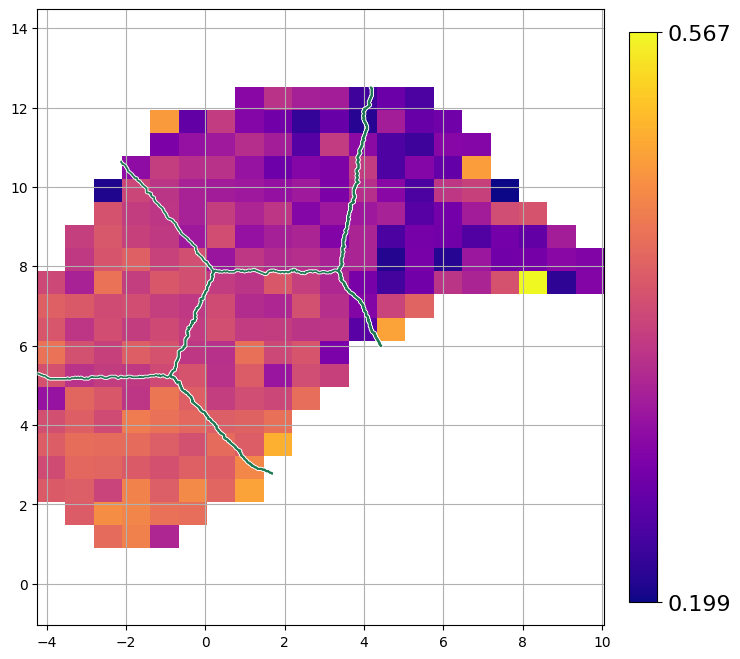

In [9]:
cmap = plt.colormaps["plasma"].copy()
cmap.set_bad(color="white")
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("white")
ax.grid(True)
ax.axis("equal")

# Color scale is based on the bins that remain visible after the min5 display filter.
visible_grid = np.where(display_mask, np.nan, grid_probability_value)
vmin = float(np.nanmin(visible_grid))
vmax = float(np.nanmax(visible_grid))
c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

cluster_embedding = each_pt_embedding
cluster_labels = np.asarray(kmeans_label.labels_)
xx, yy = np.meshgrid(
    np.linspace(min_vals[0], max_vals[0], 600),
    np.linspace(min_vals[1], max_vals[1], 600),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(cluster_embedding, cluster_labels)
Z = knn.predict(grid_points).reshape(xx.shape)

tree = cKDTree(cluster_embedding)
dist, _ = tree.query(grid_points, k=1)
Z_masked = np.ma.masked_where(dist.reshape(xx.shape) > 0.4, Z)

ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="white", linewidths=2.6, alpha=0.95, zorder=10,
)
ax.contour(
    xx, yy, Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="#1f7952", linewidths=1.2, alpha=1.0, zorder=11,
)

cbar = fig.colorbar(c2, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.3f}", f"{vmax:.3f}"])
cbar.ax.tick_params(labelsize=16)

fig.savefig(OUTPUT_STEM + ".png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_STEM + ".pdf", bbox_inches="tight")
np.savez_compressed(
    OUTPUT_STEM + "_grid.npz",
    grid_count=grid_count,
    grid_mean=grid_probability_value,
    x_bins=x_bins,
    y_bins=y_bins,
    selected_global_idx=selected_global_idx,
    each_pt_embedding=each_pt_embedding,
)
print("Saved:", OUTPUT_STEM + ".png / .pdf / _grid.npz")
plt.show()

## Optional check

Figure 6B is now the **single source** for UMAP coordinates and grid edges; the preceding heatmap cell already checks equality of all 400 bin counts *before* plotting. If the check fails, first verify `B_GRID_PATH`, rerun B's export cell, and make sure both notebooks are reading the same feature data.


In [10]:
print("Reference B file:", os.path.abspath(B_GRID_PATH))
print("Same selected global indices:", np.array_equal(b_selected_idx, selected_global_idx))
print("Same UMAP coordinates:", np.array_equal(b_embedding, each_pt_embedding))
print("Same x/y grid edges:", np.array_equal(x_bins, b_x_bins) and np.array_equal(y_bins, b_y_bins))
print("Same counts in all 400 bins:", np.array_equal(grid_count, b_grid_count))


Reference B file: /Users/dazhang/Documents/ripple_IED_paper/Figure_6/Figure6_B_grid.npz
Same selected global indices: True
Same UMAP coordinates: True
Same x/y grid edges: True
Same counts in all 400 bins: True


Cluster 1 (KMeans label 3): N=8782, Mean=0.4183, SEM=0.0039
Cluster 2 (KMeans label 2): N=5954, Mean=0.3860, SEM=0.0046
Cluster 3 (KMeans label 0): N=6155, Mean=0.3794, SEM=0.0045
Cluster 4 (KMeans label 1): N=5244, Mean=0.3310, SEM=0.0047
Cluster 5 (KMeans label 4): N=4027, Mean=0.2967, SEM=0.0052


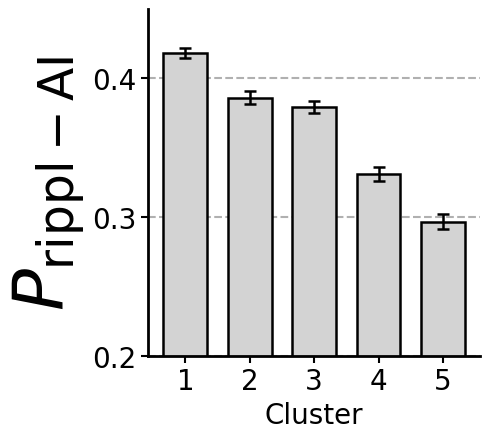

In [11]:
# ======================================================
# Figure 6D: Cluster Mean Rippl-AI Probability ± SEM
# Based on Figure6_D_corrected_v2.ipynb
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# Use the existing results from Figure6_D_corrected_v2
cluster_labels = np.asarray(kmeans_label.labels_)
probabilities = np.asarray(each_pt_probs)

assert len(probabilities) == EXPECTED_SELECTED_N
assert len(cluster_labels) == len(probabilities)

# Preserve the previous Rippl-AI bar display order
cluster_display_order = [3, 2, 0, 1, 4]

cluster_data = [
    probabilities[cluster_labels == cluster_id]
    for cluster_id in cluster_display_order
]

# Calculate cluster mean
cluster_means = [
    np.nanmean(data)
    for data in cluster_data
]

# Calculate cluster SEM
cluster_sems = [
    np.nanstd(data, ddof=1) /
    np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]

# Print actual statistics
for bar_idx, (cluster_id, data, mean, sem) in enumerate(
    zip(
        cluster_display_order,
        cluster_data,
        cluster_means,
        cluster_sems
    ),
    start=1
):
    print(
        f"Cluster {bar_idx} (KMeans label {cluster_id}): "
        f"N={len(data)}, "
        f"Mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )

# ======================================================
# Plot
# ======================================================

labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

ax.bar(
    x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

ax.set_xlabel("Cluster", fontsize=20)

ax.set_ylabel(
    r"$P_{\mathrm{rippl-AI}}$",
    fontsize=50
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)

ax.tick_params(axis="y", labelsize=20)

ax.set_ylim(0.25, 0.45)
ax.set_yticks(np.arange(0.2, 0.45, 0.1))

ax.set_axisbelow(True)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.tick_params(
    axis="both",
    width=1.5,
    length=5
)

plt.tight_layout()

# Save figures
fig.savefig(
    "Figure6_D_corrected_v2_bar.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "Figure6_D_corrected_v2_bar.pdf",
    bbox_inches="tight"
)

plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_probability_scatter(
    embedding,
    probabilities,
    colorbar_label,
    output_stem,
    point_size=4,
    cmap="plasma",
    vmin=None,
    vmax=None
):
    embedding = np.asarray(embedding)
    probabilities = np.asarray(probabilities)

    assert embedding.shape[0] == len(probabilities), \
        f"embedding rows ({embedding.shape[0]}) != probabilities ({len(probabilities)})"

    fig, ax = plt.subplots(figsize=(8, 8))

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=probabilities,
        cmap=cmap,
        s=point_size,
        linewidths=0,
        # alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(True)
    ax.axis("equal")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(colorbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    fig.savefig(output_stem + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(output_stem + ".pdf", bbox_inches="tight")

    plt.show()

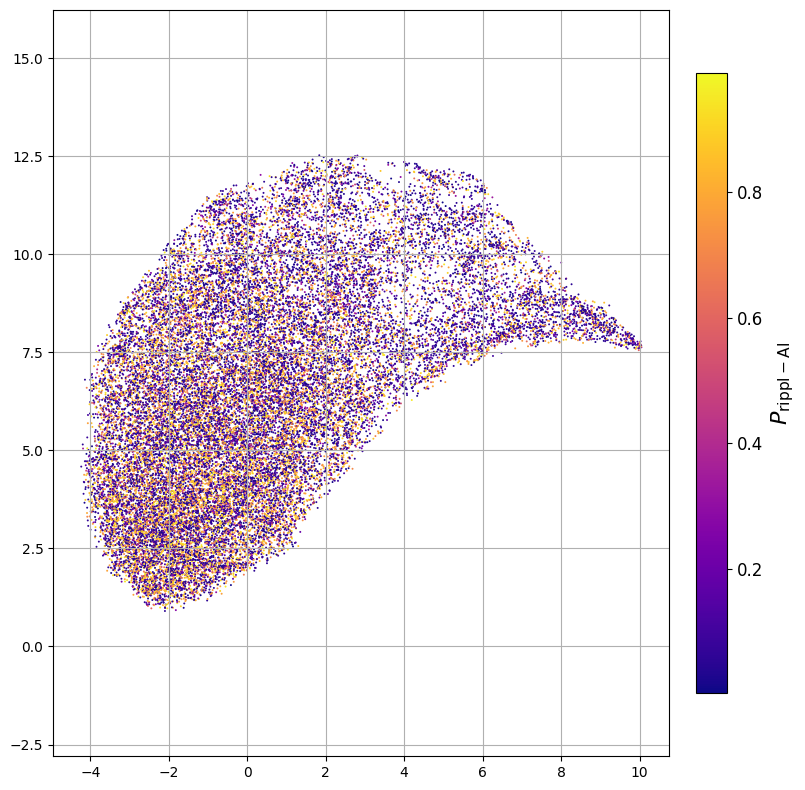

In [13]:
plot_probability_scatter(
    embedding=each_pt_embedding,
    probabilities=each_pt_probs,
    colorbar_label=r"$P_{\mathrm{rippl-AI}}$",
    output_stem="Figure6_D_corrected_scatter",
    point_size=2
)